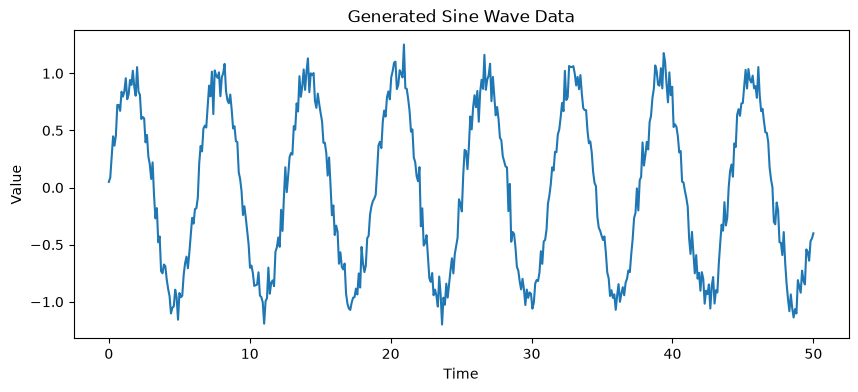

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

np.random.seed(42)

time_steps = np.linspace(0, 50, 500)
data = np.sin(time_steps) + 0.1 * np.random.randn(500)

plt.figure(figsize=(10, 4))
plt.plot(time_steps, data)
plt.title("Generated Sine Wave Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [2]:
sequence_length = 10
X, y = [], []

for i in range(len(data) - sequence_length):
    X.append(data[i : i + sequence_length])
    y.append(data[i + sequence_length])

X = np.array(X).reshape(-1, sequence_length, 1)
y = np.array(y)

split_index = int(0.8 * len(X))
X_train, X_test = X[ :split_index], X[split_index: ]
y_train, y_test = y[ :split_index], y[split_index: ]

print(f"Training sequences: {X_train.shape[0]}")
print(f"Testing sequences: {X_test.shape[0]}")

Training sequences: 392
Testing sequences: 98


In [3]:
def build_model(rnn_layer, name):
    model = Sequential(name=name)
    model.add(rnn_layer(32, input_shape=(sequence_length, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_model(SimpleRNN, "SimpleRNN")
lstm_model = build_model(LSTM, "LSTM")
gru_model = build_model(GRU, "GRU")

rnn_model.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
EPOCHS = 20
BATCH_SIZE = 16

print("Training SimpleRNN...")
hist_rnn = rnn_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test), verbose=0)

print("Training LSTM...")
hist_lstm = lstm_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test), verbose=0)

print("Training GRU...")
hist_gru = gru_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test), verbose=0)

print("Training Complete!")

Training SimpleRNN...
Training LSTM...
Training GRU...
Training Complete!


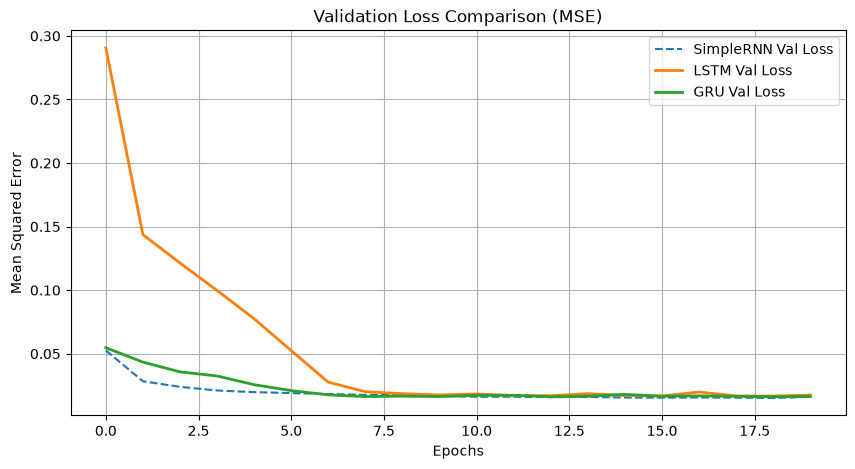

Final SimpleRNN MSE: 0.0161
Final LSTM MSE:      0.0174
Final GRU MSE:       0.0163


In [5]:
plt.figure(figsize=(10, 5))

plt.plot(hist_rnn.history['val_loss'], label='SimpleRNN Val Loss', linestyle='--')
plt.plot(hist_lstm.history['val_loss'], label='LSTM Val Loss', linewidth=2)
plt.plot(hist_gru.history['val_loss'], label='GRU Val Loss', linewidth=2)

plt.title("Validation Loss Comparison (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final SimpleRNN MSE: {hist_rnn.history['val_loss'][-1]:.4f}")
print(f"Final LSTM MSE:      {hist_lstm.history['val_loss'][-1]:.4f}")
print(f"Final GRU MSE:       {hist_gru.history['val_loss'][-1]:.4f}")